<table width="100%">
  <tr>
    <td align="left" valign="middle" width="100%">
      <img src="../docs/assets/logo_bristol.png" alt="University of Bristol" width="200" />
    </td>
    <td align="right" valign="middle" width="100%">
      <img src="../docs/assets/logo_ufpe.png" alt="UFPE" width="130" />
      &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
      <img src="../docs/assets/logo_kunumi.png" alt="Kunumi" width="150" />
      &nbsp;&nbsp;
    </td>
  </tr>
</table>

---

In [ ]:
import subprocess
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    REPO_ROOT = Path('/content/latent-ability-ml')
    if not REPO_ROOT.exists():
        subprocess.check_call([
            'git',
            'clone',
            'https://github.com/manuelfjr/latent-ability-ml.git',
            str(REPO_ROOT),
        ])

    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        '-q',
        'numpy',
        'pandas',
        'matplotlib',
        'scipy',
        'scikit-learn',
        'seaborn',
        'joblib',
        'tqdm',
        'birt-gd',
    ])

    for candidate in [REPO_ROOT, REPO_ROOT / 'notebooks', REPO_ROOT / 'utils', REPO_ROOT / 'src']:
        candidate_str = str(candidate)
        if candidate_str not in sys.path:
            sys.path.insert(0, candidate_str)

    from nb_utils import set_root
    PROJECT_ROOT = REPO_ROOT
    print(f'Running in Colab with project root: {PROJECT_ROOT}')
else:
    from nb_utils import set_root
    PROJECT_ROOT = set_root(level=2)
    print(f'Running locally with project root: {PROJECT_ROOT}')


**Environment note.** Run the setup cell above first. It loads the repository and the local modules needed for this notebook, especially when opening it in Google Colab.


# Section 1: Supervised Evaluation and Example Difficulty

This opening notebook starts from the simplest evaluation setting: supervised classification. The purpose is not to stay in ordinary accuracy tables, but to show that even here the interesting signal is often local. Some examples are easy for every model, while others remain ambiguous and informative.

## Learning Goals

By the end of this section, participants should be able to:

- compare a small supervised model pool on the same dataset;
- interpret accuracy, balanced accuracy, and F1 together rather than in isolation;
- inspect which examples are systematically difficult or disagreement-prone;
- connect supervised example difficulty to the later latent-variable view of items.

In [1]:
import matplotlib.pyplot as plt

from utils.handson import (
    evaluate_models_on_dataset,
    make_toy_classification_dataset,
    plot_classification_dataset,
    plot_example_difficulty,
    summarize_classification_results,
    summarize_instance_difficulty,
)

## Step 1: Build a toy supervised dataset

We start with a two-dimensional classification problem so that the room can read the geometry directly.

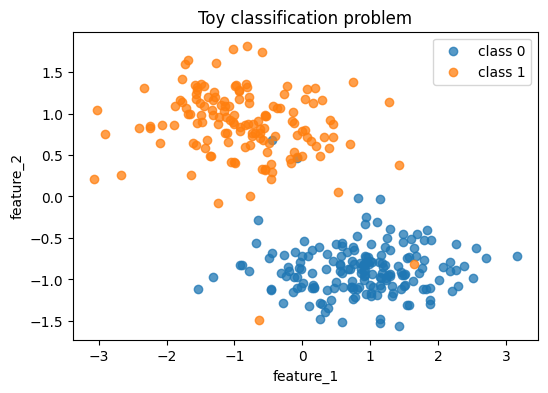

In [2]:
df = make_toy_classification_dataset(
    n_samples=320,
    class_sep=0.9,
    flip_y=0.05,
    weights=(0.55, 0.45),
    random_state=7,
)

fig, ax = plt.subplots(figsize=(6, 4))
plot_classification_dataset(df, ax=ax)
plt.show()

## Step 2: Compare several supervised models

Now we train a compact pool of classifiers and summarize their test-set behavior. The important point is not only who wins, but how the metrics differ and what those differences suggest.

In [3]:
results = evaluate_models_on_dataset(df, scenario='supervised_demo', random_state=7)
summary = summarize_classification_results(results, scenario='supervised_demo')
summary.sort_values('balanced_accuracy', ascending=False)

,scenario,model,accuracy,balanced_accuracy,f1,mean_difficulty_proxy
1,supervised_demo,knn,0.989583,0.988372,0.988235,0.037500
2,supervised_demo,logistic_regression,0.989583,0.988372,0.988235,0.093168
0,supervised_demo,decision_tree,0.979167,0.976744,0.976190,0.011364


## Step 3: Move from model scores to example difficulty

Instead of stopping at model-level metrics, we aggregate behavior per example. The difficulty proxy becomes higher when models stay uncertain or disagree with one another.

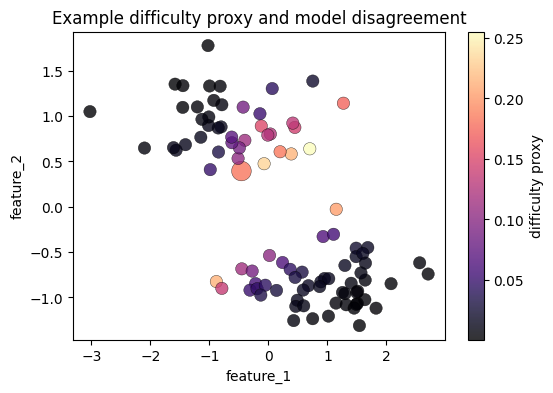

,scenario,example_id,feature_1,feature_2,label,mean_correct,mean_predicted_probability,mean_difficulty_proxy,disagreement
65,supervised_demo,224,1.640204,-0.809424,1,0.000000,0.003179,0.006359,0
24,supervised_demo,79,-0.457061,0.392532,1,0.666667,0.575570,0.182193,1
36,supervised_demo,119,0.700774,0.637754,1,1.000000,0.872342,0.255316,0
85,supervised_demo,287,-0.072851,0.473372,1,1.000000,0.883315,0.233370,0
8,supervised_demo,27,0.386823,0.581161,1,1.000000,0.892657,0.214685,0
74,supervised_demo,250,-0.881983,-0.825696,0,1.000000,0.107235,0.214471,0
66,supervised_demo,230,1.149405,-0.029083,0,1.000000,0.102035,0.204069,0
23,supervised_demo,78,0.198316,0.605260,1,1.000000,0.908595,0.182810,0
79,supervised_demo,269,1.271237,1.139975,1,1.000000,0.913836,0.172328,0
84,supervised_demo,279,-0.120717,0.888868,1,1.000000,0.923687,0.152627,0


In [4]:
example_summary = summarize_instance_difficulty(results)

fig, ax = plt.subplots(figsize=(6, 4))
plot_example_difficulty(example_summary, ax=ax)
plt.show()

example_summary.head(10)

## Step 4: Read supervised evaluation as a response matrix

The bridge to IRT appears when we rewrite supervised evaluation as a response matrix. Rows are models, columns are examples, and each entry records whether a model classified that example correctly. In IRT language, models start to look like respondents, examples start to look like items, and correctness becomes the binary response.

This does not mean that ordinary supervised metrics are useless. It means that the metrics are summaries of a richer relational object. The response matrix lets us ask which examples are easy, which examples are hard, and which examples actually separate stronger and weaker models.

In [5]:
hard_examples = example_summary.head(5)['example_id'].tolist()
response_matrix = (
    results[results['example_id'].isin(hard_examples)]
    .assign(correct=lambda frame: (frame['label'] == frame['predicted_label']).astype(int))
    .pivot(index='model', columns='example_id', values='correct')
    .sort_index()
)

response_matrix

example_id,27,79,119,224,287
model,,,,,
decision_tree,1,0,1,0,1
knn,1,1,1,0,1
logistic_regression,1,1,1,0,1


## Bridge to Binary IRT and 2PL

The next section gives this matrix a probabilistic interpretation. Instead of only saying that one model has higher accuracy, we ask how model ability interacts with item difficulty. Instead of only saying that one example was misclassified, we ask whether that example behaves like a genuinely hard item or like an item that discriminates between models.

That is the reason the workshop moves from supervised evaluation directly into IRT: the supervised setting gives us the intuition, and IRT gives us the language.

## Discussion Prompts

- Which metric is most sensitive to class imbalance in this toy setting?
- Which examples stay ambiguous across several models?
- Why is it useful to discuss example-level difficulty even when labels are available?
- How does this prepare the transition to IRT, where items become explicit objects of analysis?